# Week 6 - Outbound



## Part 1 - Refactored Loop

## Helpers for the upcoming section

In [9]:
import numpy as np

# 4 sensings, 3 binary tells each, shape (4, 3)
tells = np.array([[1, 0, 1], # foot shift, no guard drop, exhale
                  [0, 1, 1], # no shift, guard drop, exhale
                  [0, 0, 1], # only exhale
                  [1, 1, 1]]) # all three (the bluff)

# Ground truth: 1 = strike imminent, 0 = they will hold
strike = np.array([[1, 1, 0, 0]]).T # column vector, shape (4, 1)

# ReLU and its derivative
relu = lambda x: np.where(x > 0, x, 0)
relu2deriv = lambda x: np.where(x > 0, 1, 0)

This is the main call for looping through the epochs and inputs. The training is kept to a one line to help show the simple nature of the looping. This also takes into account our hidden layer sizes to set the weights and prepare to loop through.

In [10]:
def train(tells, strike, alpha, epochs, hidden_size, seed, verbose = False):
    # Set random seed so results can be reproduced
    np.random.seed(seed)

    # Initialize weights randomly between -1 and 1
    weights_0_1 = 2 * np.random.random((tells.shape[1], hidden_size)) - 1 # layer 0 to layer 1, shape (tells.shape[1], hidden_size)
    weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1 # layer 1 to layer 2, shape (hidden_size, 1)

    # Track total error for each epoch
    error_history = [0.0] * epochs

    # Loop through the dataset for the given number of epochs
    for epoch in range(epochs):
        total_error = 0

        # Process each sensing sample one at a time (Stochastic GD)
        for i in range(len(tells)):
            _, _, _, _, _, weights_0_1, weights_1_2, total_error = onestep(tells, strike, i, weights_0_1, weights_1_2, alpha, total_error)

        # Save this epoch's total error
        error_history[epoch] = total_error

        # Print total squared error every 10 epochs
        # +1 so it doesn't print right away
        if (epoch + 1) % 10 == 0:
            if verbose:
                print(f"Epoch {epoch + 1:2d} | Total Error: {total_error:.6f}")

    # Return final weights and error log
    return weights_0_1, weights_1_2, error_history

onestep is a easy function to compact the steps of the training process:
Forward Pass
Compare
Backward
Update Weights

In [11]:
def onestep(tells, strike, idx, weights_0_1, weights_1_2, alpha, total_error):
    """
    One step of the Predict-Compare-Learn loop
    Parameters:
    `tells` (in): the dataset
    `strike` (in): labels for the dataset
    `idx` (in): index with which to get the current tell/strike
    `weights_0_1` (in): weight matrix from layer_0 to layer_1
    `weights_1_2` (in): weight matrix from layer_1 to layer_2
    `alpha` (in): alpha value used to reign in weight updates
    `total_error` (in): total error for the overall epoch
    """
    layer_0 = tells[idx:idx+1]
    target = strike[idx:idx+1]

    # --- FORWARD ---
    layer_1 = relu(layer_0 @ weights_0_1) # (1, hidden_size)
    layer_2 = layer_1 @ weights_1_2 # (1, 1)

    # --- COMPARE ---
    total_error += np.sum((layer_2 - target) ** 2) # (1, 1)

    # --- BACKWARD ---
    layer_2_delta = layer_2 - target # (1, 1)
    layer_1_delta = layer_2_delta @ weights_1_2.T * relu2deriv(layer_1) # (1, hidden_size)

    # --- LEARN ---
    weights_0_1 -= alpha * layer_0.T @ layer_1_delta # (3, 1) @ (1, hidden_size) -> broadcast over shape (3, hidden_size) -> (3, hidden_size)
    weights_1_2 -= alpha * layer_1.T @ layer_2_delta # (hidden_size, 1) @ (1, 1) -> broadcast over shape (hidden_size, 1) -> (hidden_size, 1)

    return layer_0, layer_1, layer_2, layer_1_delta, layer_2_delta, weights_0_1, weights_1_2, total_error

In [12]:
w0_1, w1_2, error_history = train(tells, strike, 0.2, 60, 4, 1)
print(w0_1)
print(w1_2)
print(error_history)

[[-0.16595599  0.91056768 -0.99977125 -0.90023925]
 [-0.70648822 -0.92794391 -0.62747958  0.89703458]
 [-0.20646505 -0.03308324 -0.16161097  0.00237016]]
[[-0.5910955 ]
 [ 1.13962134]
 [-0.94522481]
 [ 1.11023793]]
[np.float64(1.4142058374213209), np.float64(1.212716151470694), np.float64(1.056563760006402), np.float64(0.9491664812884164), np.float64(0.8619621154574514), np.float64(0.784506838338833), np.float64(0.7146489816005345), np.float64(0.672866352346484), np.float64(0.6394999890740327), np.float64(0.6342311598444467), np.float64(0.5969764839869187), np.float64(0.5714302583039846), np.float64(0.547512509993337), np.float64(0.5291187885056882), np.float64(0.5202827123839309), np.float64(0.4854443591208563), np.float64(0.4804341717307572), np.float64(0.42548955696355173), np.float64(0.3905776418458242), np.float64(0.3583840767631752), np.float64(0.32618123814841266), np.float64(0.29395962452752283), np.float64(0.26209322300616283), np.float64(0.23101665519209996), np.float64(0.201

## Part 2 - Architectures

This was a documentation section breaking down how the diagram looks. This is used in part 3 for the visuals in it's implementation.

# Wider
layer_0 --[ weights_0_1 (3, 32), relu ]--> layer_1 --[ weights_1_2 (32, 1) ]--> layer_2
(1, 3) (1, 32) (1, 1)
Weights: 3x32 + 32x1 = 128

# Deeper
layer_0 --[ weights_0_1 (3, 4), relu ]--> layer_1 --[ weights_1_2 (4, 4), relu ] --> layer_2 --[ weights_2_3 (4, 4), relu ] -->layer_3 --[ weights_3_4 (4, 1) ] --> layer_4
(1, 3) (1, 4) (1, 4) (1, 4) (1, 1)
Weights: 3x4 + 4x4 + 4x4 + 4x4 + 4x1 = 64

# Multi-output
layer_0 --[ weights_0_1 (3, 8), relu ]--> layer_1 --[ weights_1_2 (8, 4) ]--> layer_2
(1, 3) (1, 8) (1, 4)
Weights: 3x8 + 8x4 = 56

# Custom
### 16 measurements from a brain activity sensor are used to classify whether a person is resting, focused, or moving
layer_0 --[ weights_0_1 (16, 32), relu ]--> layer_1 --[ weights_1_2 (32, 16) ]--> layer_2 --[ weights_2_3 (16, 3)]--> layer_3
(1, 16) (1, 32) (1, 16) (1, 3)
Weights: 16x32 + 32x16 + 16x3 = 1072

## Part 3 - Build from Diagram

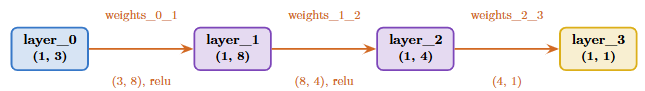

This section is implementing the above diagram into code.

## Helpers for the upcoming section

In [13]:
import numpy as np

# 4 sensings, 3 binary tells each
tells = np.array([[1, 0, 1], # foot shift, no guard drop, exhale
[0, 1, 1], # no shift, guard drop, exhale
[0, 0, 1], # only exhale
[1, 1, 1]]) # all three (the bluff)

# Ground truth: 1 = strike imminent, 0 = they will hold
strike = np.array([[1, 1, 0, 0]]).T # column vector, shape (4, 1)

# applies relu to a numpy array
def relu(input):
    return input * (input > 0)

# multiplies a numpy array by presumed relu's derivative
def relu2deriv(input):
    return input > 0

# works on an arbitrary length of net, assuming relu on all but the last step
# input as row vectors, matrices as input dims x output dims
# assumes input and all entries in weight_mats are numpy arrays
# (not weight_mats itself, which is not)
def forward(input, weight_mats):
    saved = [0] * (len(weight_mats) + 1)
    saved[0] = input
    cur = input
    # 1 less loop than there are weight matrices, see below
    for i in range(len(weight_mats) - 1):
        cur = relu(cur @ weight_mats[i])
        saved[i+1] = cur
    # no relu on the last step
    cur = cur @ weight_mats[-1]
    saved[-1] = cur
    return saved

Below is the implementation of the diagram given.

In [14]:
# I don't like the idea of writing a function for a particular shape;
# this function works for any shape, but defaults to the assignment spec shape.
def train_from_diagram(tells, strike, alpha, epochs, seed, layer_lens = [3, 8, 4, 1]):
    # initialize weight matrices, sizes calculated from layer_lens.
    # so for e.g. layer_lens of (3, 4, 1), this would initialize 2
    # matrices, a 3x4 and a 4x1
    np.random.seed(seed)
    weight_mats = [0] * (len(layer_lens) - 1)
    for i in range(len(layer_lens) - 1):
        weight_mats[i] = 2*np.random.random((layer_lens[i], layer_lens[i+1])) - 1

    # make an empty error history
    # for each epoch.
    err_hist = [0] * epochs

    # for each epoch...
    for epoch in range(epochs):
        # for each tell...
        for i in range(len(tells)):
            # run a forward pass, saving all the layers
            # including layer 0, the input
            layers = forward(tells[i:i+1], weight_mats)
            # make an empty deltas list
            deltas = [0] * len(weight_mats)
            # set the last delta, since its process is a bit special
            deltas[-1] = layers[-1] - strike[i:i+1]

            # add in our error before we go on, since we only need
            # this delta to calculate it
            err_hist[epoch] += deltas[-1]**2

            # set all the other deltas (1 less iteration than there
            # are deltas, since we already set the last one)
            for j in range(len(deltas) - 1):
                deltas[-j-2] = deltas[-j-1] @ weight_mats[-j-1].T * relu2deriv(layers[-j-2])

            # do the actual weight updating
            for j in range(len(weight_mats)):
                weight_mats[j] = weight_mats[j] - alpha * np.outer(layers[j], deltas[j])
        # print error every 30 epochs
        if epoch % 30 == 29:
            print(err_hist[epoch])
    # run one more forward pass for each and print it
    return [forward(input, weight_mats)[-1] for input in tells]

print(train_from_diagram(tells, strike, 0.1, 150, 4, layer_lens = [3, 8, 4, 1]))
print(strike[:])


[[0.00196853]]
[[3.86880513e-07]]
[[6.64437858e-11]]
[[1.14075625e-14]]
[[1.98946723e-18]]
[array([1.]), array([1.]), array([8.99536295e-10]), array([1.17063556e-11])]
[[1]
 [1]
 [0]
 [0]]


## Holocron -- Reading

It's a fundamental documentation principle. When you're designing a database, you don't just start using "create table". You draw out what that database should look like, table by table, how they connect, etc. That's documentation. The same thing is with creating a diagram of a network. It's a visual documentation to reference. Even if you create a neural network and it never changes, you would have to spend time down the road if you needed to verify or understand something. An architect doesn't just do some quick calculations and start building a tower. This kind of engineering quickly becomes complicated as you drill down and without a clear to read starting point, you're only making more trouble for yourself.

The holocron exerpt sounds a lot like the example of a man who built his house on the sand vs the one who built it on the rock. Without a diagram, you have no foundation to build on.